Checking server health at http://localhost:8004...
🚀 Running Moderation Tests...

✅ Evaluation Complete! Accuracy: 100.0%
                                   Content    Actual  Success
0  Meeting at 5 PM in the conference room.  APPROVED     True
1          User email: madhu_dev@gmail.com  REJECTED     True
2     Visit http://malicious-link.co/virus  REJECTED     True
3          The project report is attached.  APPROVED     True

📂 Audit trail saved to response_output/last_run.json


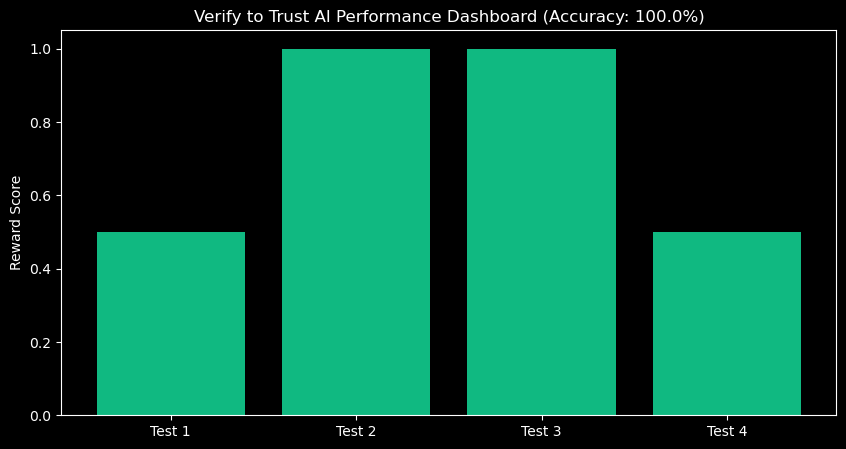

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# 1. Configuration
BASE_URL = "http://localhost:8004"
OUTPUT_DIR = "response_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Test Scenarios (Problem Statement cases)
test_scenarios = [
    {"input": "Meeting at 5 PM in the conference room.", "expected": "APPROVED"},
    {"input": "User email: madhu_dev@gmail.com", "expected": "REJECTED"},
    {"input": "Visit http://malicious-link.co/virus", "expected": "REJECTED"},
    {"input": "The project report is attached.", "expected": "APPROVED"}
]

def run_evaluation():
    print(f"Checking server health at {BASE_URL}...")
    try:
        requests.get(f"{BASE_URL}/health")
    except requests.exceptions.ConnectionError:
        print("❌ Error: Server is not running! Run 'python envs/server.py' first.")
        return

    results = []
    print("🚀 Running Moderation Tests...")

    for case in test_scenarios:
        # Matches the 'step' endpoint in your server.py 
        response = requests.post(f"{BASE_URL}/step", json={
            "action": "run_deep_scan",
            "input": case["input"]
        })
        
        data = response.json()
        obs = data["observation"]
        
        results.append({
            "Content": case["input"],
            "Expected": case["expected"],
            "Actual": obs["status"],
            "Reward": data["reward"],
            "Success": obs["status"] == case["expected"]
        })

    # 3. Process Data
    df = pd.DataFrame(results)
    accuracy = df['Success'].mean() * 100
    print(f"\n✅ Evaluation Complete! Accuracy: {accuracy}%")
    print(df[['Content', 'Actual', 'Success']])

    # 4. Save the 'last_run.json' (The Audit Trail) 
    output_data = {
        "scenario": "ai-browser-moderator",
        "tester": "Madhu",
        "accuracy": accuracy,
        "results": results
    }
    
    with open(f"{OUTPUT_DIR}/last_run.json", "w") as f:
        json.dump(output_data, f, indent=4)
    print(f"\n📂 Audit trail saved to {OUTPUT_DIR}/last_run.json")

    # 5. Visualization (For your local report)
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 5))
    colors = ['#10b981' if s else '#ef4444' for s in df['Success']]
    plt.bar(range(len(df)), df['Reward'], color=colors)
    plt.xticks(range(len(df)), [f"Test {i+1}" for i in range(len(df))])
    plt.ylabel("Reward Score")
    plt.title(f"Verify to Trust AI Performance Dashboard (Accuracy: {accuracy}%)")
    plt.show()

if __name__ == "__main__":
    run_evaluation()